<a href="https://colab.research.google.com/github/JacekDrzycimski/6tunnel/blob/master/segy2hdf5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Install Required Libraries
We need `segyio` to read the SEG-Y files and `h5py` (usually pre-installed in Colab) to write HDF5 files.

In [1]:
!pip install segyio h5py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 4.9 MB/s eta 0:00:00


### 2. Define the Conversion Function
This script reads the seismic traces, headers, and structural dimensions from the SEG-Y file and stores them into an HDF5 dataset structure.

In [2]:
import segyio
import h5py
import numpy as np

def segy_to_hdf5(segy_path, hdf5_path, dataset_name='seismic'):
    """
    Converts a SEG-Y file to an HDF5 file.
    """
    print(f"Opening SEG-Y file: {segy_path}")
    with segyio.open(segy_path, "r", ignore_geometry=False) as segyfile:
        # Read cube metrics
        num_traces = segyfile.tracecount
        sample_rate = segyio.tools.dt(segyfile) / 1000.0  # in ms
        num_samples = len(segyfile.samples)

        print(f"Traces: {num_traces}, Samples per trace: {num_samples}, Sample Rate: {sample_rate} ms")

        # Try to read as a 3D volume, otherwise fall back to pre-trace reading
        try:
            volume = segyio.tools.cube(segyfile)
            is_3d = True
            print(f"Detected 3D volume with shape: {volume.shape}")
        except ValueError:
            is_3d = False
            print("Could not structure as 3D cube. Reading trace-by-trace instead.")

        # Create HDF5 file
        with h5py.File(hdf5_path, 'w') as h5file:
            if is_3d:
                # Save structured 3D volume
                dset = h5file.create_dataset(dataset_name, data=volume, compression="gzip", compression_opts=4)
            else:
                # Save trace-by-trace 2D representation
                data_matrix = np.zeros((num_traces, num_samples), dtype=np.float32)
                for i in range(num_traces):
                    data_matrix[i, :] = segyfile.trace[i]
                dset = h5file.create_dataset(dataset_name, data=data_matrix, compression="gzip", compression_opts=4)

            # Save metadata as attributes
            dset.attrs['sample_rate_ms'] = sample_rate
            dset.attrs['is_3d'] = is_3d

            print(f"Successfully saved data to HDF5: {hdf5_path} with compression.")

# Example usage (Replace with your actual file paths):
# segy_to_hdf5('input.segy', 'output.h5')

### 3. Mount Google Drive and Upload
Once converted, you can mount your Google Drive and save/move the output `.h5` file directly to your Drive.

In [3]:
from google.colab import drive
# drive.mount('/content/drive')

# You can copy the generated HDF5 file to your drive:
# !cp output.h5 /content/drive/MyDrive/

### 3.1 Google Drive Mount Details
Mounting your Google Drive lets you permanently save your `.segy` and converted `.h5` files so they do not get deleted when your Google Colab session expires.

In [9]:
from google.colab import drive

# Mount your Google Drive at /content/drive
drive.mount('/content/drive')

# List contents of My Drive to verify the mount
import os
if os.path.exists('/content/drive/MyDrive'):
    print("Successfully mounted! Here are files in your Google Drive:")
    print(os.listdir('/content/drive/MyDrive')[:5])  # Display first 5 items

Mounted at /content/drive
Successfully mounted! Here are files in your Google Drive:
['jacek.drzycimski - Contact form [Contact form].gform', 'jacek.drzycimski - Contact form.gsheet', 'jacek.drzycimski - Tutorial: Google for Webmasters.gslides', 'OJC050104040008.BHZ', 'OJC050104040008.BHN']


### 3.2 List Google Drive Files
Run this cell to view the files currently stored in your Google Drive root directory (`My Drive`).

In [10]:
import os

drive_path = '/content/drive/MyDrive'
if os.path.exists(drive_path):
    print(f"Listing contents of {drive_path}:")
    drive_files = os.listdir(drive_path)
    for file in sorted(drive_files):
        print(f"- {file}")
else:
    print("Google Drive is not mounted yet. Please run the cell above to mount it first.")

Listing contents of /content/drive/MyDrive:
- 1. python basics
- 12821466_199269893778164_5169984553283764166_n.jpg
- 18 Sun OT A.pdf
- 19 Sun in OT A.pdf
- 2. data analysis with python
- 20 Bible Timeline responses (1).pdf
- 20 Bible Timeline responses.pdf
- 20 Bible timeline session.pdf
- 2012_FB_IJones_NearSurface_better_ver.pdf
- 2013_FB_IJones_orthogonal-tutorial_better_ver.pdf
- 2016-07-15 09.06.55.jpg
- 2017-04-23 07.47.44.jpg
- 20170209_154631.jpg
- 20181228_112420.jpg
- 20181228_112437.jpg
- 20200228_121402.mp4
- 2020_11_5_Muttenz_NearSurface_stacks_PSTMs.pptx
- 2023-07-12_Statement (1).pdf
- 2023-07-12_Statement.pdf
- 20230223_024749.jpg
- 20230223_024753.jpg
- 20230223_024756.jpg
- 20230223_024838.jpg
- 20230223_034350.jpg
- 2024-bank_statements_JacekDrzycimski.zip
- 2024_invoices_Hydenlyne-Ltd_HydroEnergyGroup_JacekDrzycimski.zip
- 2025-01-12_Statement.pdf
- 2025-02-12_Statement.pdf
- 2026 CAF - Parent Information .pdf
- 21st Sunday in Ordinary Time (1).pdf
- 21st Sunday in

In [15]:
!pip install obspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 65.8 MB/s eta 0:00:00


In [1]:
import obspy
import h5py

# Define your input and output file paths inside Google Drive
input_segy_path = '/content/drive/MyDrive/OJC050104040008.BHZ'
output_hdf5_path = '/content/drive/MyDrive/seismic_output.h5'

try:
    # Use ObsPy to parse passive seismology formats (.BHZ, MiniSEED, etc.)
    print(f"Reading file via ObsPy: {input_segy_path}")
    stream = obspy.read(input_segy_path)

    print(f"Loaded {len(stream)} trace(s).")

    with h5py.File(output_hdf5_path, 'w') as h5file:
        for i, trace in enumerate(stream):
            # Save trace data
            dataset_name = f"trace_{i}" if len(stream) > 1 else "seismic"
            dset = h5file.create_dataset(dataset_name, data=trace.data, compression="gzip", compression_opts=4)

            # Save metadata attributes
            dset.attrs['sampling_rate_hz'] = trace.stats.sampling_rate
            dset.attrs['station'] = trace.stats.station
            dset.attrs['channel'] = trace.stats.channel

    print(f"Successfully saved data to HDF5: {output_hdf5_path}")
except Exception as e:
    print(f"Error processing file: {e}")

Reading file via ObsPy: /content/drive/MyDrive/OJC050104040008.BHZ
Loaded 1 trace(s).
Successfully saved data to HDF5: /content/drive/MyDrive/seismic_output.h5


In [12]:
# Quickly verify the conversion and check the shape of the generated file
print_dataset_shape(output_hdf5_path)


Error: File not found at '/content/drive/MyDrive/seismic_output.h5'. Make sure you have converted and saved your file first.


### 4. Inspect the Converted HDF5 File
You can use the following helper function to look inside the HDF5 file to verify its structure, dimensions, and saved metadata attributes.

In [2]:
def inspect_hdf5(hdf5_path):
    """
    Inspects and prints the structure and metadata of an HDF5 file.
    """
    print(f"Inspecting HDF5 file: {hdf5_path}\n" + "-"*40)
    with h5py.File(hdf5_path, 'r') as f:
        # Recursively print groups and datasets
        def print_structure(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"Dataset: {name}")
                print(f"  Shape: {obj.shape}")
                print(f"  Datatype: {obj.dtype}")
                if len(obj.attrs) > 0:
                    print("  Attributes:")
                    for key, val in obj.attrs.items():
                        print(f"    {key}: {val}")
            elif isinstance(obj, h5py.Group):
                print(f"Group: {name}")

        f.visititems(print_structure)

# Example usage (Uncomment to inspect your file):
# inspect_hdf5('output.h5')

In [7]:
# Inspect the newly converted seismic HDF5 file
inspect_hdf5('/content/drive/MyDrive/seismic_output.h5')

Inspecting HDF5 file: /content/drive/MyDrive/seismic_output.h5
----------------------------------------
Dataset: seismic
  Shape: (144000,)
  Datatype: int32
  Attributes:
    channel: BHZ
    sampling_rate_hz: 20.0
    station: OJC


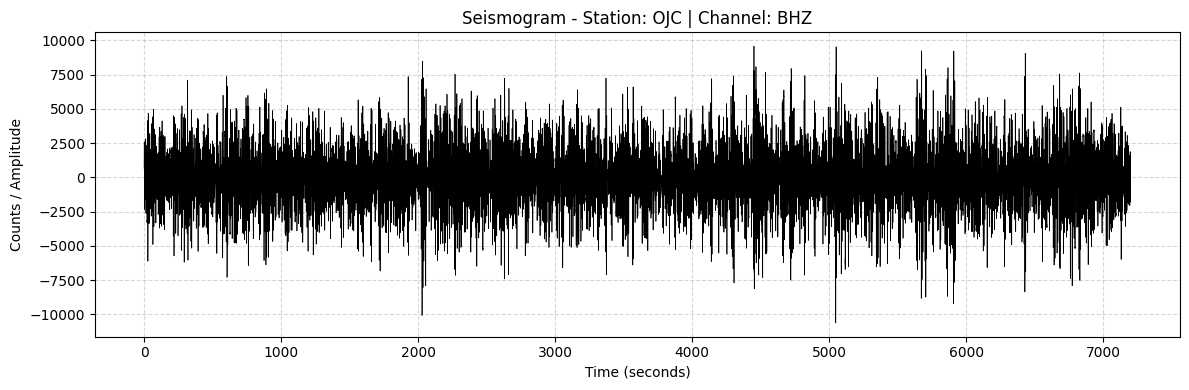

In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def plot_1d_seismogram(hdf5_path, dataset_name='seismic'):
    with h5py.File(hdf5_path, 'r') as f:
        if dataset_name in f:
            data = f[dataset_name][:]
            attrs = f[dataset_name].attrs

            # Extract metadata
            rate = attrs.get('sampling_rate_hz', 1.0)
            station = attrs.get('station', 'Unknown')
            channel = attrs.get('channel', 'Unknown')

            # Create time axis in seconds
            time = np.arange(len(data)) / rate

            # Plotting
            plt.figure(figsize=(12, 4))
            plt.plot(time, data, color='black', linewidth=0.5)
            plt.title(f"Seismogram - Station: {station} | Channel: {channel}")
            plt.xlabel("Time (seconds)")
            plt.ylabel("Counts / Amplitude")
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()
        else:
            print(f"Dataset {dataset_name} not found.")

# Plot the converted data
plot_1d_seismogram('/content/drive/MyDrive/seismic_output.h5')

In [9]:
import h5py

hdf5_path = '/content/drive/MyDrive/seismic_output.h5'

with h5py.File(hdf5_path, 'r') as f:
    if 'seismic' in f:
        dataset = f['seismic']
        num_samples = dataset.shape[0]
        sampling_rate = dataset.attrs.get('sampling_rate_hz', 20.0)

        # Duration in seconds
        duration_seconds = num_samples / sampling_rate
        # Duration in minutes
        duration_minutes = duration_seconds / 60.0

        print(f"Dataset Path: {hdf5_path}")
        print(f"Total Samples: {num_samples}")
        print(f"Sampling Rate: {sampling_rate} Hz")
        print(f"Total Duration: {duration_seconds:.2f} seconds")
        print(f"Total Duration: {duration_minutes:.2f} minutes")
    else:
        print("Dataset 'seismic' not found in the HDF5 file.")

Dataset Path: /content/drive/MyDrive/seismic_output.h5
Total Samples: 144000
Sampling Rate: 20.0 Hz
Total Duration: 7200.00 seconds
Total Duration: 120.00 minutes


In [13]:
import h5py
import numpy as np

hdf5_path = '/content/drive/MyDrive/seismic_output.h5'

with h5py.File(hdf5_path, 'r') as f:
    if 'seismic' in f:
        data = f['seismic'][:]
        mean_val = np.mean(data)
        std_val = np.std(data)

        print(f"Seismic Amplitude Statistics:")
        print(f"----------------------------")
        print(f"Mean Amplitude:               {mean_val:.4f}")
        print(f"Standard Deviation:           {std_val:.4f}")
        print(f"Minimum Amplitude:            {np.min(data)}")
        print(f"Maximum Amplitude:            {np.max(data)}")
    else:
        print("Dataset 'seismic' not found in the HDF5 file.")

Seismic Amplitude Statistics:
----------------------------
Mean Amplitude:               0.1132
Standard Deviation:           2406.8067
Minimum Amplitude:            -10613
Maximum Amplitude:            9582


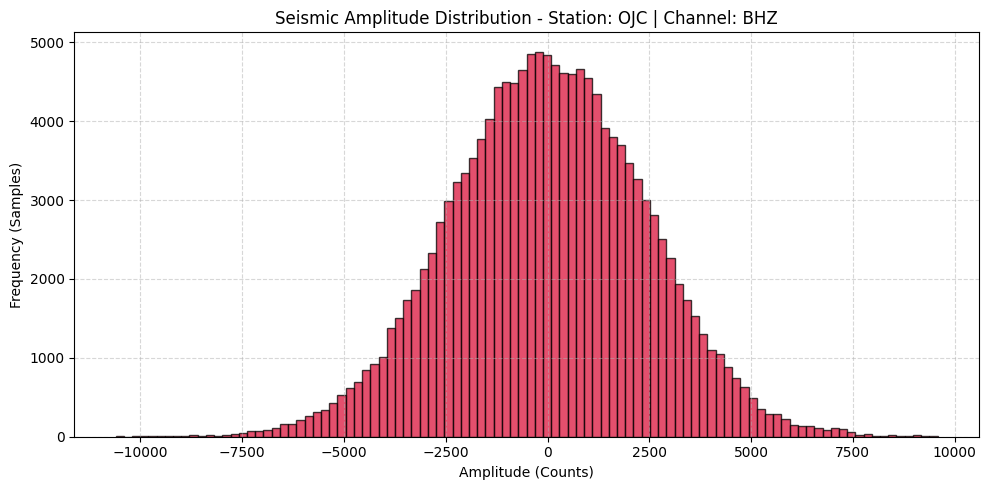

In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

hdf5_path = '/content/drive/MyDrive/seismic_output.h5'

with h5py.File(hdf5_path, 'r') as f:
    if 'seismic' in f:
        data = f['seismic'][:]
        attrs = f['seismic'].attrs
        station = attrs.get('station', 'Unknown')
        channel = attrs.get('channel', 'Unknown')

        # Plotting the histogram of amplitudes
        plt.figure(figsize=(10, 5))
        plt.hist(data, bins=100, color='crimson', edgecolor='black', alpha=0.75)
        plt.title(f"Seismic Amplitude Distribution - Station: {station} | Channel: {channel}")
        plt.xlabel("Amplitude (Counts)")
        plt.ylabel("Frequency (Samples)")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print("Dataset 'seismic' not found in the HDF5 file.")

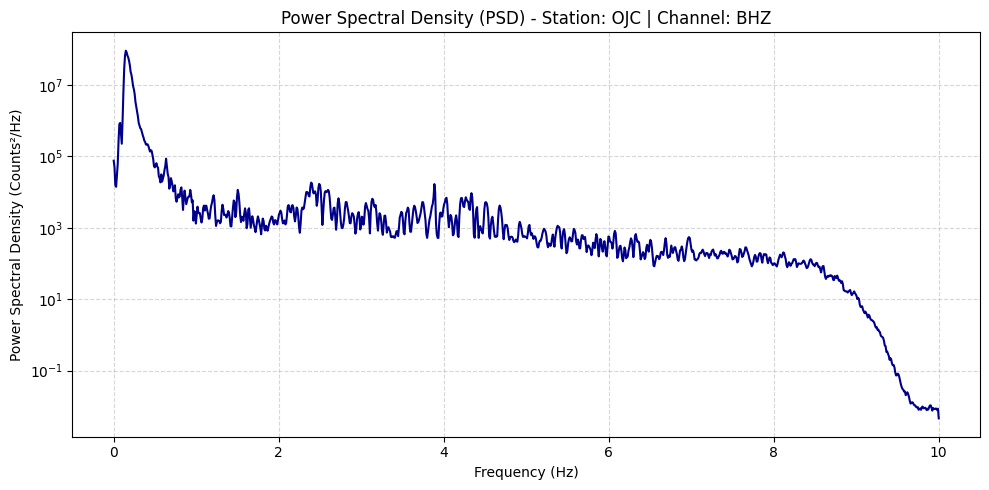

In [15]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

hdf5_path = '/content/drive/MyDrive/seismic_output.h5'

with h5py.File(hdf5_path, 'r') as f:
    if 'seismic' in f:
        data = f['seismic'][:]
        sampling_rate = f['seismic'].attrs.get('sampling_rate_hz', 20.0)
        station = f['seismic'].attrs.get('station', 'Unknown')
        channel = f['seismic'].attrs.get('channel', 'Unknown')

        # Compute PSD using Welch's method
        frequencies, psd = welch(data, fs=sampling_rate, nperseg=2048)

        # Plot PSD in dB scale
        plt.figure(figsize=(10, 5))
        plt.semilogy(frequencies, psd, color='darkblue', linewidth=1.5)
        plt.title(f"Power Spectral Density (PSD) - Station: {station} | Channel: {channel}")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power Spectral Density (Counts²/Hz)")
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print("Dataset 'seismic' not found in the HDF5 file.")

In [16]:
import h5py
import numpy as np

hdf5_path = '/content/drive/MyDrive/seismic_output.h5'

with h5py.File(hdf5_path, 'r') as f:
    if 'seismic' in f:
        data = f['seismic'][:]

        # Express SNR as the ratio of root-mean-square (RMS) signal strength to background noise.
        # Since we don't have a separate noise-only window, we can compute the ratio of the peak amplitude
        # to the RMS of the rest of the trace as an estimate (Peak-to-RMS SNR),
        # or calculate a standard signal RMS versus a quiet baseline portion.

        signal_rms = np.sqrt(np.mean(data**2))

        # Estimate noise RMS using the median absolute deviation (MAD) which is robust to transient signals
        mad = np.median(np.abs(data - np.median(data)))
        noise_rms_est = mad / 0.6745  # Scale factor for normal distribution

        snr_linear = signal_rms / noise_rms_est if noise_rms_est > 0 else 0
        snr_db = 20 * np.log10(snr_linear) if snr_linear > 0 else 0

        print("Seismic Signal-to-Noise Ratio (SNR) Estimation:")
        print("-------------------------------------------------")
        print(f"Signal RMS:               {signal_rms:.4f}")
        print(f"Estimated Noise RMS (MAD): {noise_rms_est:.4f}")
        print(f"SNR (Linear):             {snr_linear:.4f}")
        print(f"SNR (Decibels / dB):      {snr_db:.4f} dB")
    else:
        print("Dataset 'seismic' not found in the HDF5 file.")

Seismic Signal-to-Noise Ratio (SNR) Estimation:
-------------------------------------------------
Signal RMS:               2406.8068
Estimated Noise RMS (MAD): 2401.7791
SNR (Linear):             1.0021
SNR (Decibels / dB):      0.0182 dB


In [17]:
import obspy
import h5py
import numpy as np

# Paths to the vertical (BHZ) and horizontal (BHN) files
bhz_path = '/content/drive/MyDrive/OJC050104040008.BHZ'
bhn_path = '/content/drive/MyDrive/OJC050104040008.BHN'

def calculate_snr(file_path):
    # Load trace
    stream = obspy.read(file_path)
    trace = stream[0]
    data = trace.data

    # Signal RMS
    signal_rms = np.sqrt(np.mean(data**2))

    # Noise RMS estimate using MAD
    mad = np.median(np.abs(data - np.median(data)))
    noise_rms_est = mad / 0.6745

    # SNR Calculations
    snr_linear = signal_rms / noise_rms_est if noise_rms_est > 0 else 0
    snr_db = 20 * np.log10(snr_linear) if snr_linear > 0 else 0

    return {
        'station': trace.stats.station,
        'channel': trace.stats.channel,
        'samples': len(data),
        'signal_rms': signal_rms,
        'noise_rms': noise_rms_est,
        'snr_linear': snr_linear,
        'snr_db': snr_db
    }

try:
    # Process both channels
    bhz_results = calculate_snr(bhz_path)
    bhn_results = calculate_snr(bhn_path)

    # Print comparison table
    print("Seismic Channel SNR Comparison")
    print("=" * 60)
    print(f"Metric                     | Channel: {bhz_results['channel']} (Vertical)  | Channel: {bhn_results['channel']} (Horizontal)")
    print("-" * 60)
    print(f"Station                    | {bhz_results['station']:<22} | {bhn_results['station']:<24}")
    print(f"Total Samples              | {bhz_results['samples']:<22} | {bhn_results['samples']:<24}")
    print(f"Signal RMS                 | {bhz_results['signal_rms']:<22.4f} | {bhn_results['signal_rms']:<24.4f}")
    print(f"Estimated Noise RMS (MAD)  | {bhz_results['noise_rms']:<22.4f} | {bhn_results['noise_rms']:<24.4f}")
    print(f"Linear SNR                 | {bhz_results['snr_linear']:<22.4f} | {bhn_results['snr_linear']:<24.4f}")
    print(f"SNR (Decibels / dB)        | {bhz_results['snr_db']:<22.4f} dB | {bhn_results['snr_db']:<24.4f} dB")
    print("=" * 60)

except Exception as e:
    print(f"Error processing or comparing channels: {e}")

Seismic Channel SNR Comparison
Metric                     | Channel: BHZ (Vertical)  | Channel: BHN (Horizontal)
------------------------------------------------------------
Station                    | OJC                    | OJC                     
Total Samples              | 144000                 | 144000                  
Signal RMS                 | 2406.8068              | 2249.2308               
Estimated Noise RMS (MAD)  | 2401.7791              | 2257.9689               
Linear SNR                 | 1.0021                 | 0.9961                  
SNR (Decibels / dB)        | 0.0182                 dB | -0.0337                  dB


Calculating cross-correlation for 144000 samples at 20.0 Hz...


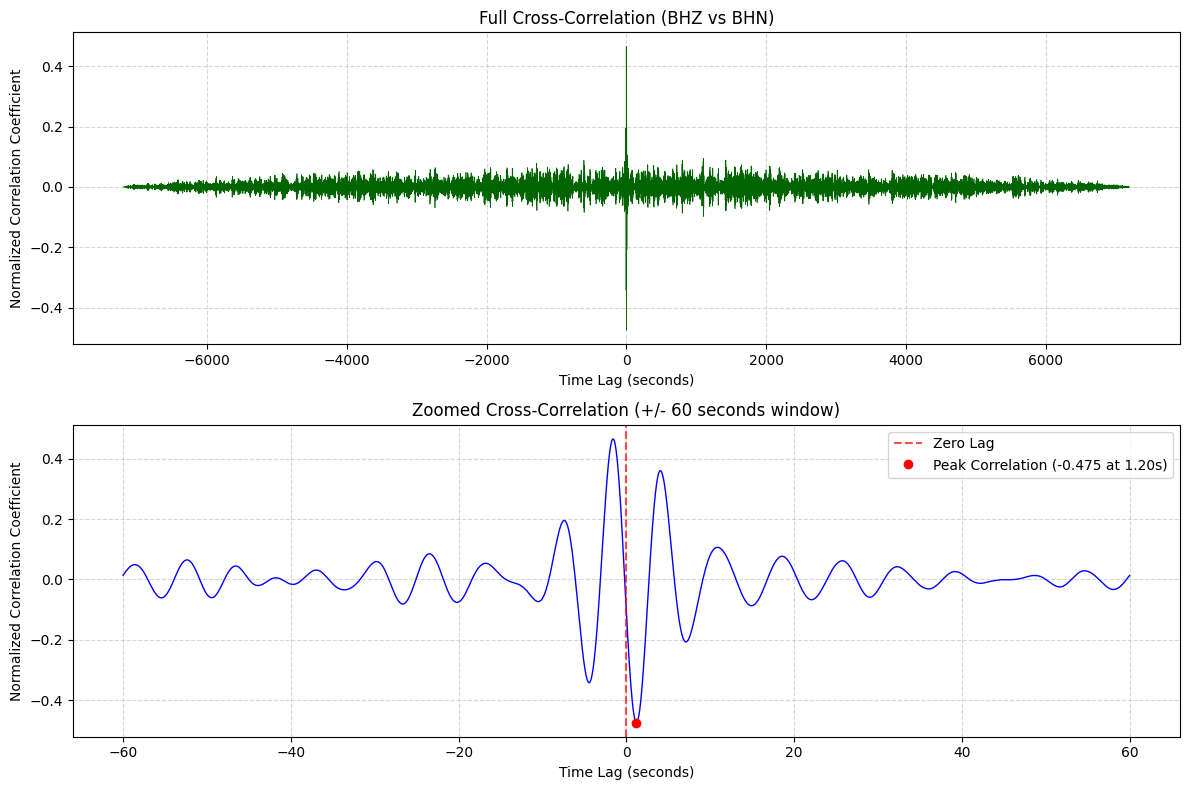

Analysis Summary:
Maximum Absolute Correlation: -0.4747
Time Lag at Peak:             1.20 seconds


In [18]:
import obspy
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

# Paths to the BHZ and BHN files
bhz_path = '/content/drive/MyDrive/OJC050104040008.BHZ'
bhn_path = '/content/drive/MyDrive/OJC050104040008.BHN'

try:
    # Load both traces
    stream_z = obspy.read(bhz_path)
    stream_n = obspy.read(bhn_path)

    trace_z = stream_z[0]
    trace_n = stream_n[0]

    # Extract data and remove mean
    data_z = trace_z.data - np.mean(trace_z.data)
    data_n = trace_n.data - np.mean(trace_n.data)

    sampling_rate = trace_z.stats.sampling_rate
    n_samples = len(data_z)

    print(f"Calculating cross-correlation for {n_samples} samples at {sampling_rate} Hz...")

    # Compute normalized cross-correlation
    # Normalize the signals to get correlation coefficients between -1 and 1
    norm_z = np.sqrt(np.sum(data_z**2))
    norm_n = np.sqrt(np.sum(data_n**2))

    # Perform cross-correlation
    corr = correlate(data_z, data_n, mode='full') / (norm_z * norm_n)

    # Generate time lag axis (in seconds)
    lags = np.arange(-n_samples + 1, n_samples) / sampling_rate

    # Define a maximum lag window to display (e.g., +/- 60 seconds) for fine visual inspection
    max_display_lag_sec = 60
    mask = (lags >= -max_display_lag_sec) & (lags <= max_display_lag_sec)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot 1: Full-length cross-correlation
    ax1.plot(lags, corr, color='darkgreen', linewidth=0.5)
    ax1.set_title("Full Cross-Correlation (BHZ vs BHN)")
    ax1.set_xlabel("Time Lag (seconds)")
    ax1.set_ylabel("Normalized Correlation Coefficient")
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Zoomed-in cross-correlation
    ax2.plot(lags[mask], corr[mask], color='blue', linewidth=1)
    ax2.axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero Lag')

    # Find peak correlation and corresponding lag
    peak_idx = np.argmax(np.abs(corr[mask]))
    peak_lag = lags[mask][peak_idx]
    peak_val = corr[mask][peak_idx]

    ax2.plot(peak_lag, peak_val, 'ro', label=f'Peak Correlation ({peak_val:.3f} at {peak_lag:.2f}s)')
    ax2.set_title(f"Zoomed Cross-Correlation (+/- {max_display_lag_sec} seconds window)")
    ax2.set_xlabel("Time Lag (seconds)")
    ax2.set_ylabel("Normalized Correlation Coefficient")
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"Analysis Summary:")
    print(f"Maximum Absolute Correlation: {peak_val:.4f}")
    print(f"Time Lag at Peak:             {peak_lag:.2f} seconds")

except Exception as e:
    print(f"Error computing cross-correlation: {e}")

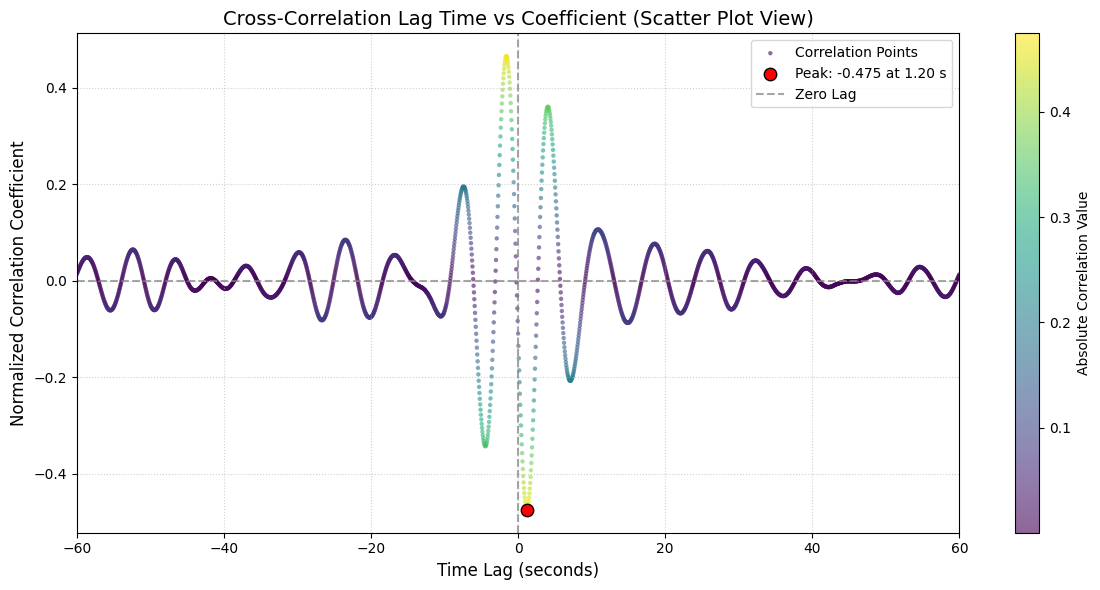

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Filter the computed cross-correlation to our visual window (+/- 60 seconds)
max_display_lag_sec = 60
mask = (lags >= -max_display_lag_sec) & (lags <= max_display_lag_sec)

selected_lags = lags[mask]
selected_corr = corr[mask]

# Identify peak values for highlighting in the plot
peak_idx = np.argmax(np.abs(selected_corr))
peak_lag = selected_lags[peak_idx]
peak_val = selected_corr[peak_idx]

# Create the scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(selected_lags, selected_corr, c=np.abs(selected_corr), cmap='viridis', s=10, alpha=0.6, edgecolors='none', label='Correlation Points')
plt.colorbar(label='Absolute Correlation Value')

# Highlight the peak correlation point
plt.scatter(peak_lag, peak_val, color='red', s=80, edgecolors='black', zorder=5,
            label=f'Peak: {peak_val:.3f} at {peak_lag:.2f} s')

plt.axvline(0, color='gray', linestyle='--', alpha=0.7, label='Zero Lag')
plt.axhline(0, color='gray', linestyle='--', alpha=0.7)

plt.title("Cross-Correlation Lag Time vs Coefficient (Scatter Plot View)", fontsize=14)
plt.xlabel("Time Lag (seconds)", fontsize=12)
plt.ylabel("Normalized Correlation Coefficient", fontsize=12)
plt.xlim(-max_display_lag_sec, max_display_lag_sec)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

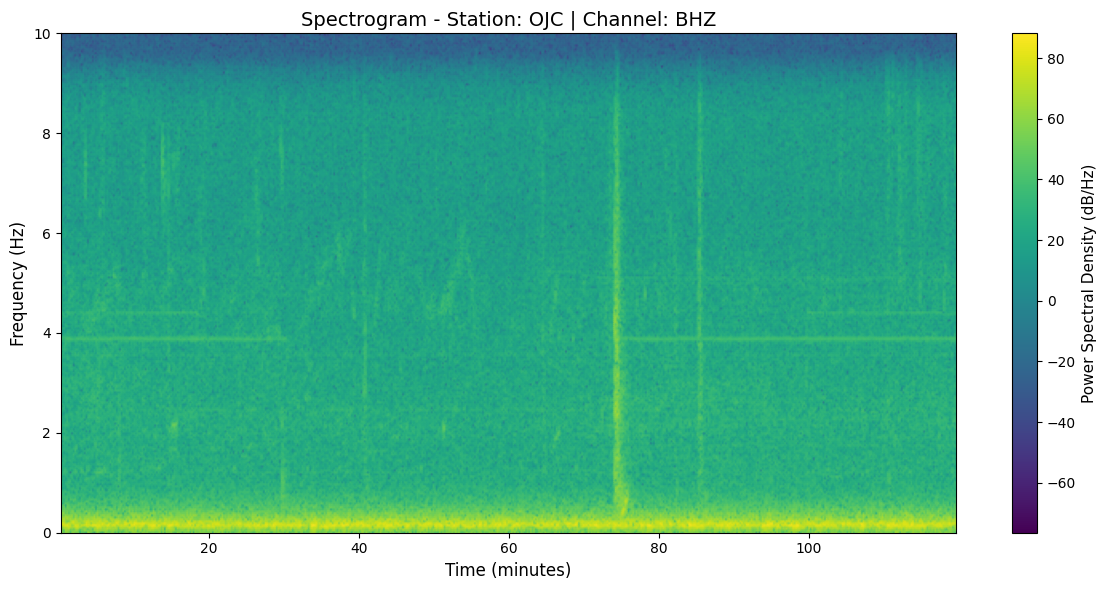

In [20]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

hdf5_path = '/content/drive/MyDrive/seismic_output.h5'

try:
    with h5py.File(hdf5_path, 'r') as f:
        if 'seismic' in f:
            data = f['seismic'][:]
            attrs = f['seismic'].attrs
            sampling_rate = attrs.get('sampling_rate_hz', 20.0)
            station = attrs.get('station', 'Unknown')
            channel = attrs.get('channel', 'Unknown')

            # Compute the spectrogram
            # Let's choose a segment length (nperseg) of 512 for a good balance of time/frequency resolution
            frequencies, times, Sxx = spectrogram(data, fs=sampling_rate, nperseg=512, noverlap=256)

            # Convert times to minutes for easier visualization over 120 minutes
            times_minutes = times / 60.0

            # Plotting the spectrogram
            plt.figure(figsize=(12, 6))
            # Using a logarithmic amplitude scale (dB) to highlight weaker signals
            plt.pcolormesh(times_minutes, frequencies, 10 * np.log10(Sxx + 1e-10), cmap='viridis', shading='gouraud')

            plt.title(f"Spectrogram - Station: {station} | Channel: {channel}", fontsize=14)
            plt.xlabel("Time (minutes)", fontsize=12)
            plt.ylabel("Frequency (Hz)", fontsize=12)
            plt.ylim(0, sampling_rate / 2)  # Up to Nyquist frequency
            cbar = plt.colorbar()
            cbar.set_label("Power Spectral Density (dB/Hz)", fontsize=11)

            plt.tight_layout()
            plt.show()
        else:
            print("Dataset 'seismic' not found in the HDF5 file.")
except Exception as e:
    print(f"Error generating spectrogram: {e}")

Reading horizontal file: /content/drive/MyDrive/OJC050104040008.BHN


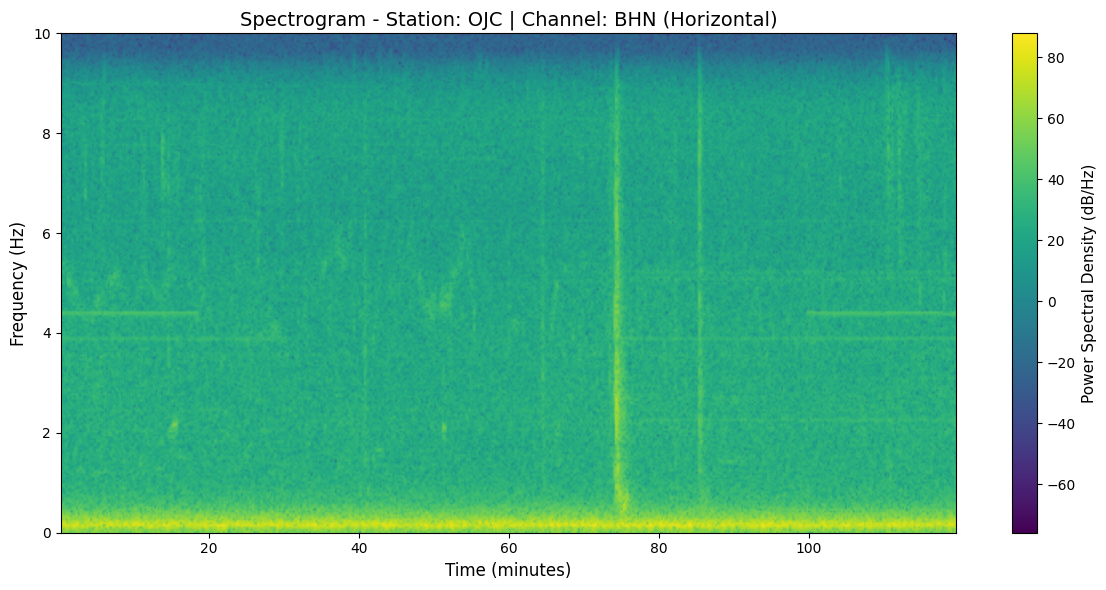

In [21]:
import obspy
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

bhn_path = '/content/drive/MyDrive/OJC050104040008.BHN'

try:
    # Load BHN component directly from the original file via ObsPy
    print(f"Reading horizontal file: {bhn_path}")
    stream_n = obspy.read(bhn_path)
    trace_n = stream_n[0]

    data_n_raw = trace_n.data
    sampling_rate = trace_n.stats.sampling_rate
    station = trace_n.stats.station
    channel = trace_n.stats.channel

    # Compute the spectrogram using identical parameters (nperseg=512, noverlap=256)
    frequencies, times, Sxx_n = spectrogram(data_n_raw, fs=sampling_rate, nperseg=512, noverlap=256)

    # Convert times to minutes
    times_minutes = times / 60.0

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(times_minutes, frequencies, 10 * np.log10(Sxx_n + 1e-10), cmap='viridis', shading='gouraud')

    plt.title(f"Spectrogram - Station: {station} | Channel: {channel} (Horizontal)", fontsize=14)
    plt.xlabel("Time (minutes)", fontsize=12)
    plt.ylabel("Frequency (Hz)", fontsize=12)
    plt.ylim(0, sampling_rate / 2)
    cbar = plt.colorbar()
    cbar.set_label("Power Spectral Density (dB/Hz)", fontsize=11)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error generating spectrogram for BHN channel: {e}")

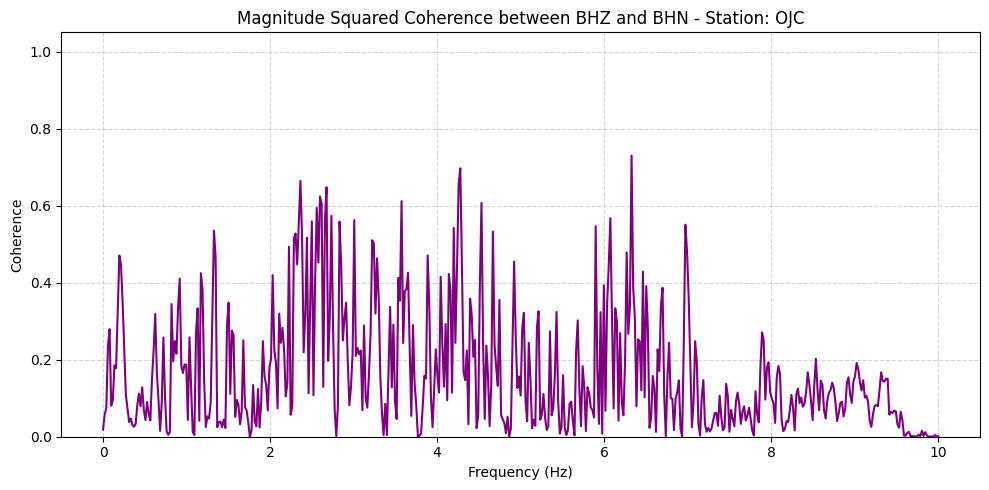

Coherence Analysis Results:
---------------------------
Mean Coherence across spectrum: 0.1660
Peak Coherence: 0.7298 at 6.328 Hz


In [22]:
import obspy
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import coherence

bhz_path = '/content/drive/MyDrive/OJC050104040008.BHZ'
bhn_path = '/content/drive/MyDrive/OJC050104040008.BHN'

try:
    # Read both traces using obspy
    stream_z = obspy.read(bhz_path)
    stream_n = obspy.read(bhn_path)

    data_z = stream_z[0].data
    data_n = stream_n[0].data
    sampling_rate = stream_z[0].stats.sampling_rate

    # Compute the magnitude squared coherence using Welch's method
    # Using standard window segment length parameters matching the previous analyses
    frequencies, coh = coherence(data_z, data_n, fs=sampling_rate, nperseg=1024)

    # Plotting coherence
    plt.figure(figsize=(10, 5))
    plt.plot(frequencies, coh, color='purple', linewidth=1.5)
    plt.title(f"Magnitude Squared Coherence between BHZ and BHN - Station: {stream_z[0].stats.station}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Coherence")
    plt.ylim(0, 1.05)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Print general insights
    mean_coherence = np.mean(coh)
    peak_coh_idx = np.argmax(coh)
    print(f"Coherence Analysis Results:")
    print(f"---------------------------")
    print(f"Mean Coherence across spectrum: {mean_coherence:.4f}")
    print(f"Peak Coherence: {coh[peak_coh_idx]:.4f} at {frequencies[peak_coh_idx]:.3f} Hz")

except Exception as e:
    print(f"Error calculating coherence: {e}")

In [23]:
import numpy as np

# Define a coherence threshold to identify strongly coupled bands
coherence_threshold = 0.3

# Find indices where coherence exceeds the threshold
above_threshold_indices = np.where(coh >= coherence_threshold)[0]

if len(above_threshold_indices) > 0:
    # Group contiguous frequency bins to define coherent bands
    bands = []
    start_idx = above_threshold_indices[0]

    for i in range(1, len(above_threshold_indices)):
        # If the index is not consecutive, a band has ended
        if above_threshold_indices[i] != above_threshold_indices[i - 1] + 1:
            end_idx = above_threshold_indices[i - 1]
            bands.append((frequencies[start_idx], frequencies[end_idx]))
            start_idx = above_threshold_indices[i]
    # Append the last band
    bands.append((frequencies[start_idx], frequencies[above_threshold_indices[-1]]))

    print(f"Coherent Frequency Bands (Threshold >= {coherence_threshold}):")
    print("-" * 50)
    for idx, (f_start, f_end) in enumerate(bands, 1):
        if f_start == f_end:
            print(f"Band {idx}: {f_start:.3f} Hz")
        else:
            print(f"Band {idx}: {f_start:.3f} Hz to {f_end:.3f} Hz")
else:
    print(f"No frequency bands found with coherence above the threshold of {coherence_threshold}.")

Coherent Frequency Bands (Threshold >= 0.3):
--------------------------------------------------
Band 1: 0.176 Hz to 0.234 Hz
Band 2: 0.625 Hz
Band 3: 0.820 Hz
Band 4: 0.898 Hz to 0.918 Hz
Band 5: 1.133 Hz
Band 6: 1.172 Hz to 1.191 Hz
Band 7: 1.309 Hz to 1.348 Hz
Band 8: 1.504 Hz
Band 9: 2.031 Hz
Band 10: 2.109 Hz
Band 11: 2.227 Hz
Band 12: 2.285 Hz to 2.383 Hz
Band 13: 2.422 Hz to 2.441 Hz
Band 14: 2.480 Hz to 2.500 Hz
Band 15: 2.539 Hz to 2.617 Hz
Band 16: 2.656 Hz to 2.676 Hz
Band 17: 2.715 Hz to 2.734 Hz
Band 18: 2.832 Hz to 2.852 Hz
Band 19: 2.891 Hz to 2.910 Hz
Band 20: 3.008 Hz
Band 21: 3.223 Hz to 3.301 Hz
Band 22: 3.438 Hz
Band 23: 3.535 Hz to 3.574 Hz
Band 24: 3.613 Hz to 3.652 Hz
Band 25: 3.887 Hz to 3.906 Hz
Band 26: 4.043 Hz
Band 27: 4.141 Hz to 4.160 Hz
Band 28: 4.199 Hz
Band 29: 4.238 Hz to 4.297 Hz
Band 30: 4.395 Hz to 4.414 Hz
Band 31: 4.512 Hz to 4.531 Hz
Band 32: 4.668 Hz
Band 33: 4.746 Hz
Band 34: 4.922 Hz
Band 35: 5.039 Hz
Band 36: 5.215 Hz
Band 37: 5.430 Hz
Band 38

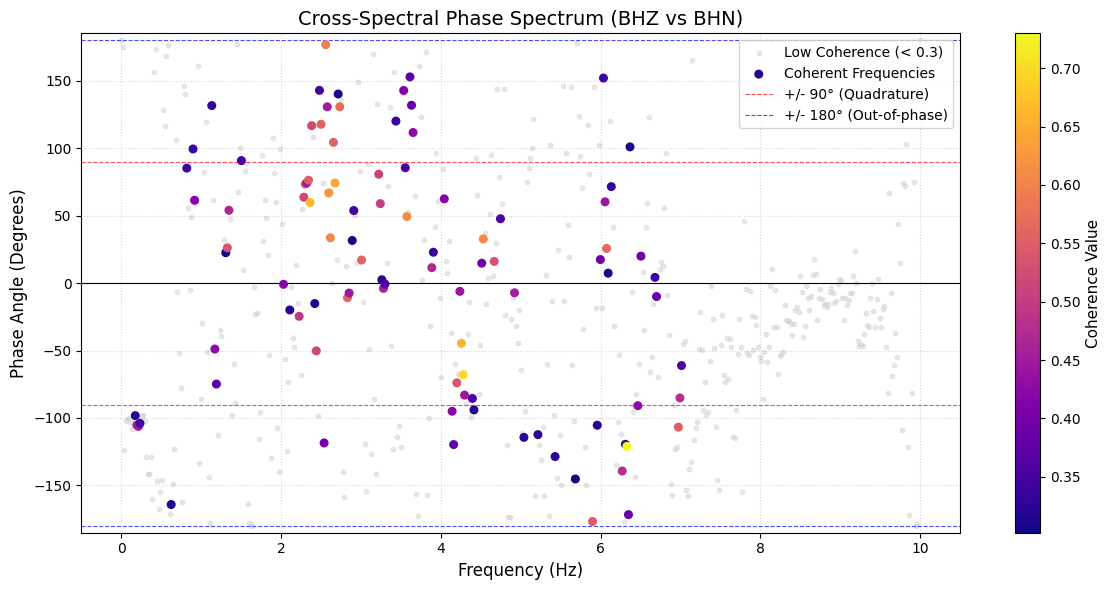

Phase at Peak Coherent Frequency (6.328 Hz): -121.04°


In [24]:
import obspy
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import csd

bhz_path = '/content/drive/MyDrive/OJC050104040008.BHZ'
bhn_path = '/content/drive/MyDrive/OJC050104040008.BHN'

try:
    # Read data streams
    stream_z = obspy.read(bhz_path)
    stream_n = obspy.read(bhn_path)
    data_z = stream_z[0].data
    data_n = stream_n[0].data
    sampling_rate = stream_z[0].stats.sampling_rate

    # Calculate Cross-Spectral Density (CSD)
    f_csd, Pxy = csd(data_z, data_n, fs=sampling_rate, nperseg=1024)

    # Calculate the phase angle in degrees
    phase_angle = np.angle(Pxy, deg=True)

    # Filter to show only the points that meet our coherence threshold (from existing 'coh' array)
    # 'frequencies' and 'coh' were calculated in the coherence step with nperseg=1024
    coh_mask = coh >= 0.3

    plt.figure(figsize=(12, 6))

    # Plot all phase angles faintly
    plt.scatter(frequencies, phase_angle, color='lightgray', s=10, alpha=0.5, label='Low Coherence (< 0.3)')

    # Highlight phase angles at coherent frequencies
    scatter = plt.scatter(frequencies[coh_mask], phase_angle[coh_mask],
                          c=coh[coh_mask], cmap='plasma', s=30, zorder=5, label='Coherent Frequencies')

    plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
    plt.axhline(90, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='+/- 90° (Quadrature)')
    plt.axhline(-90, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.axhline(180, color='blue', linestyle='--', linewidth=0.8, alpha=0.7, label='+/- 180° (Out-of-phase)')
    plt.axhline(-180, color='blue', linestyle='--', linewidth=0.8, alpha=0.7)

    plt.title("Cross-Spectral Phase Spectrum (BHZ vs BHN)", fontsize=14)
    plt.xlabel("Frequency (Hz)", fontsize=12)
    plt.ylabel("Phase Angle (Degrees)", fontsize=12)
    plt.ylim(-185, 185)
    plt.grid(True, which='both', linestyle=':', alpha=0.5)

    cbar = plt.colorbar(scatter)
    cbar.set_label('Coherence Value', fontsize=11)
    plt.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.show()

    # Inspect the phase specifically at the peak coherent frequency of 6.328 Hz
    peak_idx = np.argmax(coh)
    print(f"Phase at Peak Coherent Frequency ({frequencies[peak_idx]:.3f} Hz): {phase_angle[peak_idx]:.2f}°")

except Exception as e:
    print(f"Error calculating phase relationship: {e}")

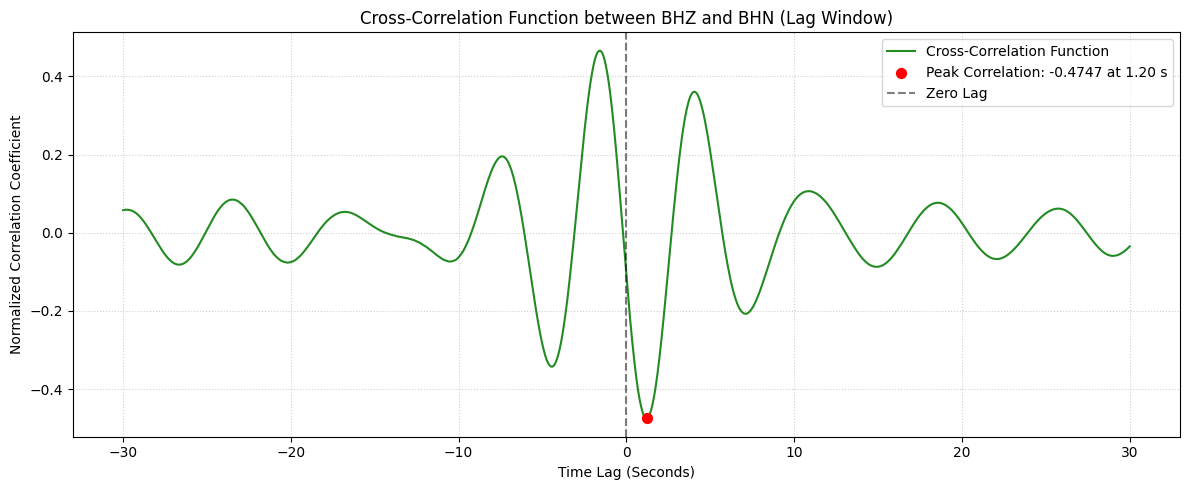

Cross-Correlation Results:
---------------------------
Peak Correlation Coefficient: -0.4747
Time Lag at Peak Coefficient: 1.20 seconds


In [25]:
import obspy
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

bhz_path = '/content/drive/MyDrive/OJC050104040008.BHZ'
bhn_path = '/content/drive/MyDrive/OJC050104040008.BHN'

try:
    # Read both channels
    stream_z = obspy.read(bhz_path)
    stream_n = obspy.read(bhn_path)

    data_z = stream_z[0].data - np.mean(stream_z[0].data)
    data_n = stream_n[0].data - np.mean(stream_n[0].data)

    sampling_rate = stream_z[0].stats.sampling_rate
    n_samples = len(data_z)

    # Calculate normalization factors
    norm_z = np.sqrt(np.sum(data_z**2))
    norm_n = np.sqrt(np.sum(data_n**2))

    # Compute normalized cross-correlation
    cc = correlate(data_z, data_n, mode='full') / (norm_z * norm_n)
    lags = np.arange(-n_samples + 1, n_samples) / sampling_rate

    # Zoom in to +/- 30 seconds to focus on the immediate physical lag window
    zoom_limit = 30
    mask_zoom = (lags >= -zoom_limit) & (lags <= zoom_limit)

    # Find peak
    peak_idx = np.argmax(np.abs(cc[mask_zoom]))
    peak_lag = lags[mask_zoom][peak_idx]
    peak_val = cc[mask_zoom][peak_idx]

    # Plotting
    plt.figure(figsize=(12, 5))
    plt.plot(lags[mask_zoom], cc[mask_zoom], color='forestgreen', label='Cross-Correlation Function')
    plt.scatter(peak_lag, peak_val, color='red', s=50, zorder=5,
                label=f'Peak Correlation: {peak_val:.4f} at {peak_lag:.2f} s')
    plt.axvline(0, color='black', linestyle='--', alpha=0.5, label='Zero Lag')

    plt.title("Cross-Correlation Function between BHZ and BHN (Lag Window)")
    plt.xlabel("Time Lag (Seconds)")
    plt.ylabel("Normalized Correlation Coefficient")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    print(f"Cross-Correlation Results:")
    print(f"---------------------------")
    print(f"Peak Correlation Coefficient: {peak_val:.4f}")
    print(f"Time Lag at Peak Coefficient: {peak_lag:.2f} seconds")

except Exception as e:
    print(f"Error calculating cross-correlation: {e}")

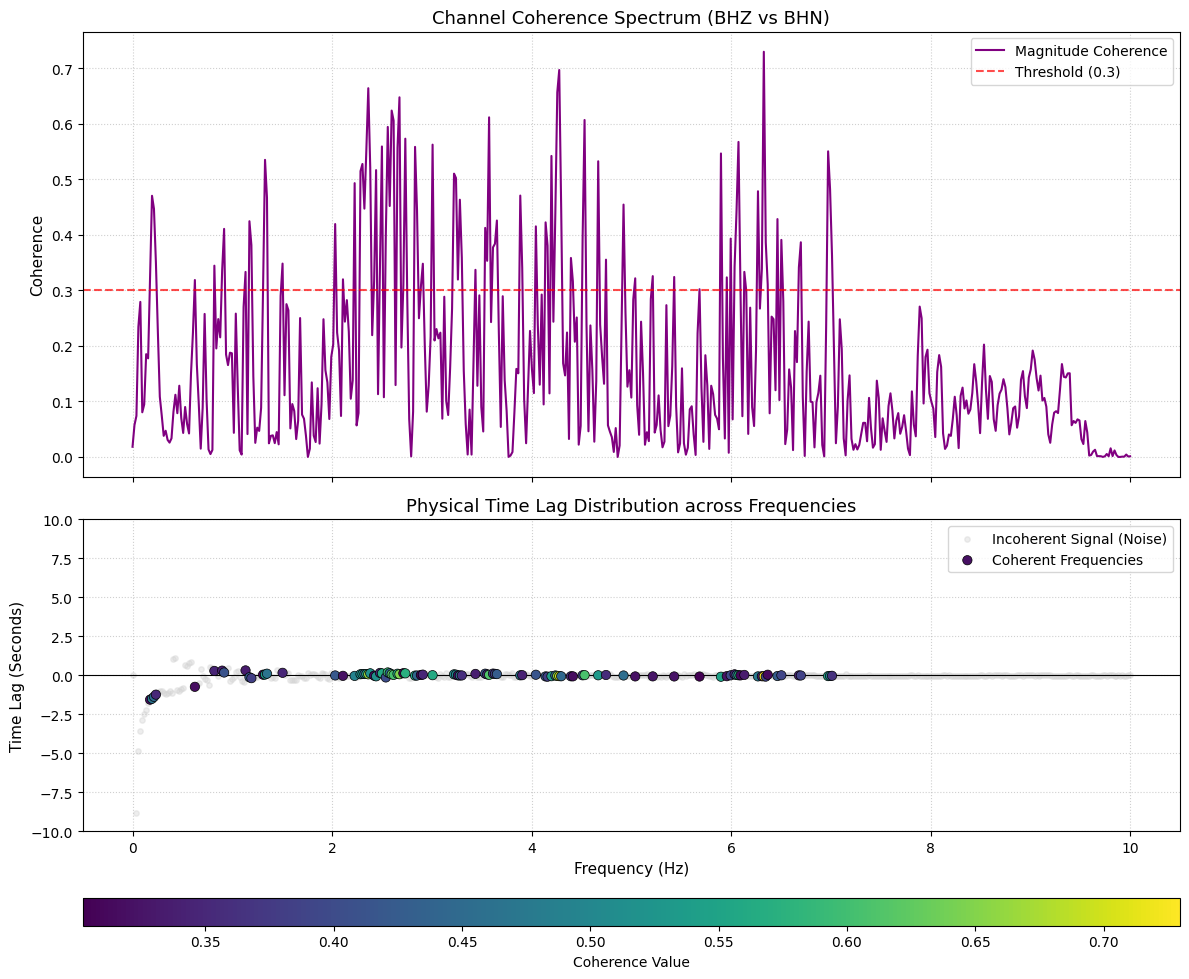

In [26]:
import obspy
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import csd, coherence

bhz_path = '/content/drive/MyDrive/OJC050104040008.BHZ'
bhn_path = '/content/drive/MyDrive/OJC050104040008.BHN'

try:
    # Load both components
    stream_z = obspy.read(bhz_path)
    stream_n = obspy.read(bhn_path)
    data_z = stream_z[0].data - np.mean(stream_z[0].data)
    data_n = stream_n[0].data - np.mean(stream_n[0].data)
    fs = stream_z[0].stats.sampling_rate

    # Calculate Coherence and CSD to get Phase
    frequencies, coh = coherence(data_z, data_n, fs=fs, nperseg=1024)
    _, Pxy = csd(data_z, data_n, fs=fs, nperseg=1024)

    # Extract phase angle in degrees
    phase_angle = np.angle(Pxy, deg=True)

    # Convert phase angle to physical time lag (seconds)
    # Prevent division by zero at 0 Hz
    time_lags = np.zeros_like(phase_angle)
    nonzero_f = frequencies > 0
    time_lags[nonzero_f] = phase_angle[nonzero_f] / (360.0 * frequencies[nonzero_f])

    # Filter using our coherence threshold of 0.3
    coherence_threshold = 0.3
    coherent_mask = coh >= coherence_threshold

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Subplot 1: Coherence
    ax1.plot(frequencies, coh, color='purple', linewidth=1.5, label='Magnitude Coherence')
    ax1.axhline(coherence_threshold, color='red', linestyle='--', alpha=0.7, label=f'Threshold ({coherence_threshold})')
    ax1.set_title("Channel Coherence Spectrum (BHZ vs BHN)", fontsize=13)
    ax1.set_ylabel("Coherence", fontsize=11)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper right')

    # Subplot 2: Physical Time Lag distribution across frequency
    # We plot all points faintly, and strongly coherent points prominently
    ax2.scatter(frequencies[~coherent_mask], time_lags[~coherent_mask],
                color='lightgray', s=15, alpha=0.4, label='Incoherent Signal (Noise)')

    sc = ax2.scatter(frequencies[coherent_mask], time_lags[coherent_mask],
                     c=coh[coherent_mask], cmap='viridis', s=45, edgecolor='black',
                     linewidths=0.5, zorder=5, label='Coherent Frequencies')

    ax2.axhline(0, color='black', linestyle='-', linewidth=0.8)
    ax2.set_title("Physical Time Lag Distribution across Frequencies", fontsize=13)
    ax2.set_xlabel("Frequency (Hz)", fontsize=11)
    ax2.set_ylabel("Time Lag (Seconds)", fontsize=11)

    # Let's set a reasonable y-limit around major arrivals (e.g., +/- 10 seconds) for visualization clarity
    ax2.set_ylim(-10, 10)
    ax2.grid(True, linestyle=':', alpha=0.6)

    # Colorbar and legend
    cbar = fig.colorbar(sc, ax=ax2, orientation='horizontal', pad=0.15, aspect=40)
    cbar.set_label('Coherence Value', fontsize=10)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error plotting lag distribution: {e}")

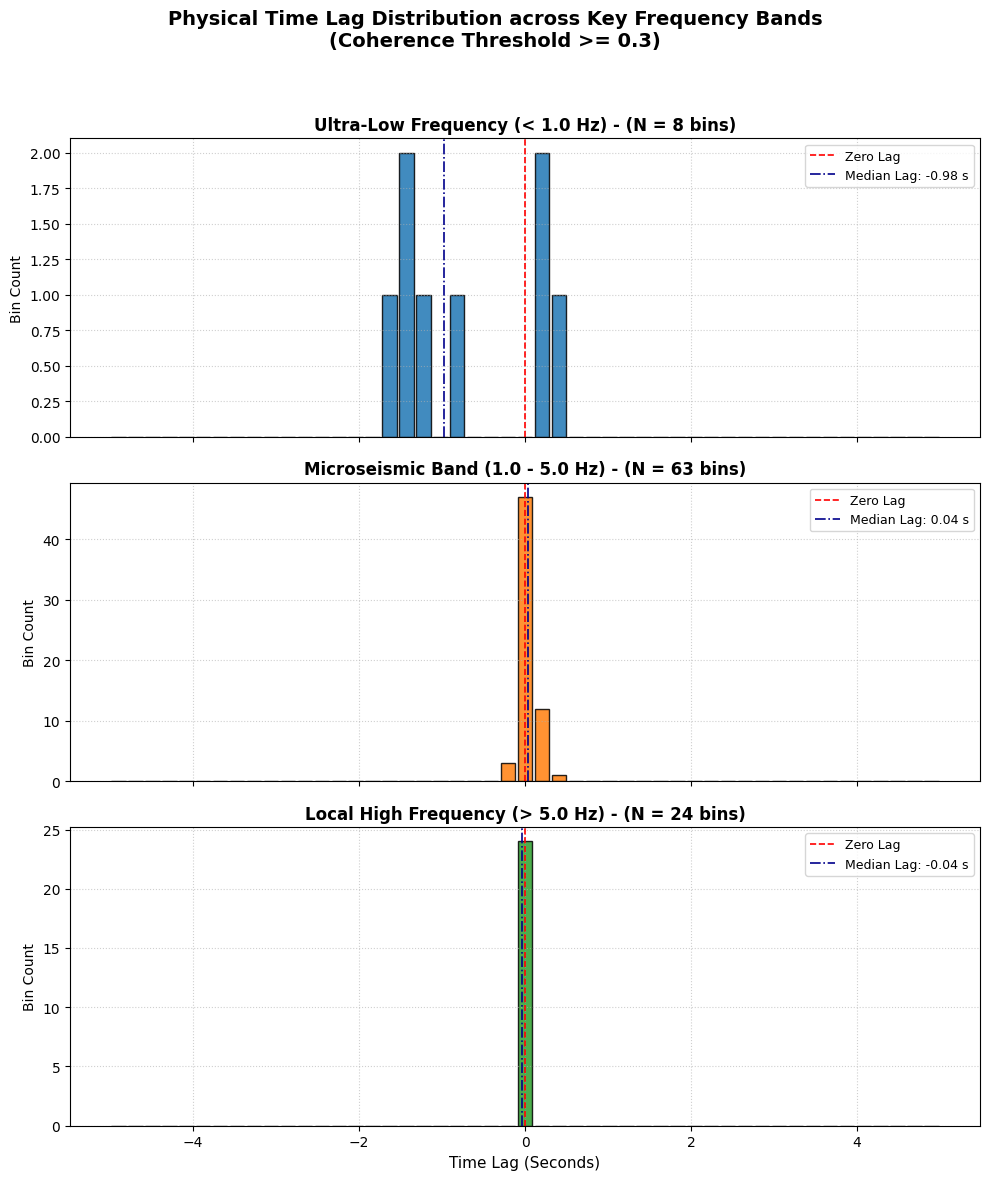

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Filter to coherent signals only
coherent_frequencies = frequencies[coherent_mask]
coherent_lags = time_lags[coherent_mask]
coherent_coherence = coh[coherent_mask]

# Define our frequency bands
bands_definitions = [
    ("Ultra-Low Frequency (< 1.0 Hz)", coherent_frequencies < 1.0),
    ("Microseismic Band (1.0 - 5.0 Hz)", (coherent_frequencies >= 1.0) & (coherent_frequencies <= 5.0)),
    ("Local High Frequency (> 5.0 Hz)", coherent_frequencies > 5.0)
]

# Plotting distribution
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (name, mask_band) in enumerate(bands_definitions):
    ax = axes[i]
    band_lags = coherent_lags[mask_band]

    if len(band_lags) > 0:
        # We limit the x-range to +/- 5 seconds to focus on meaningful physical travel-time delays
        counts, bins, patches = ax.hist(band_lags, bins=np.linspace(-5, 5, 50),
                                        color=colors[i], edgecolor='black', alpha=0.85, rwidth=0.85)

        # Add vertical line at zero lag
        ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero Lag')

        # Annotate statistical summaries
        median_lag = np.median(band_lags)
        ax.axvline(median_lag, color='darkblue', linestyle='-.', linewidth=1.2,
                   label=f'Median Lag: {median_lag:.2f} s')

        ax.set_title(f"{name} - (N = {len(band_lags)} bins)", fontsize=12, fontweight='semibold')
        ax.set_ylabel("Bin Count", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)
    else:
        ax.text(0.5, 0.5, "No coherent frequencies in this band",
                horizontalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(name, fontsize=12, fontweight='semibold')

axes[-1].set_xlabel("Time Lag (Seconds)", fontsize=11)
plt.suptitle("Physical Time Lag Distribution across Key Frequency Bands\n(Coherence Threshold >= 0.3)",
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

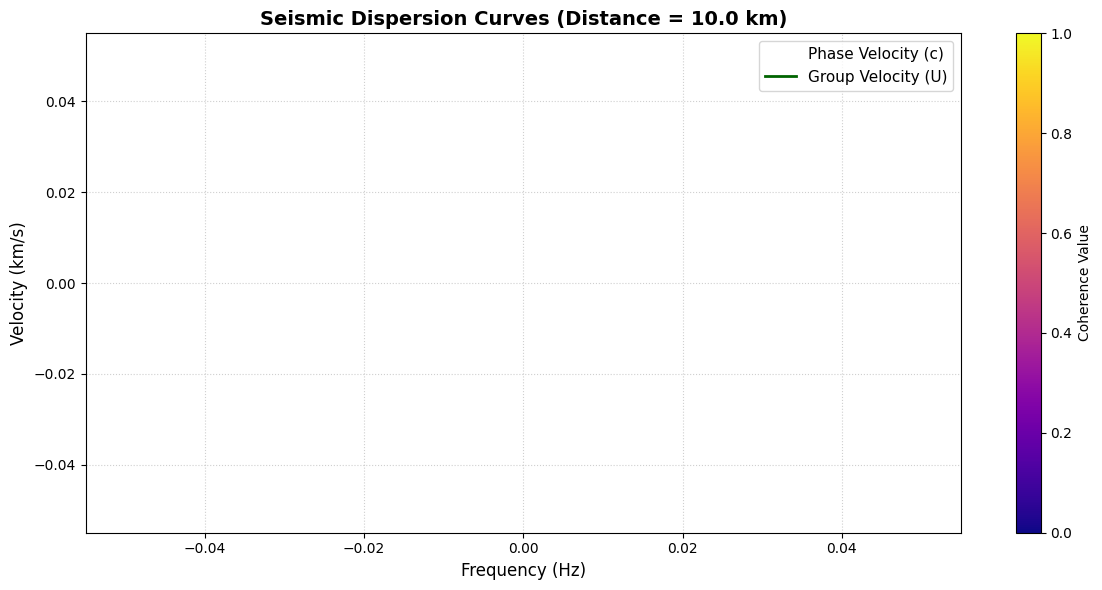

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==========================================
# USER INPUT: Update this distance to match your actual sensor separation (in km)
# ==========================================
distance_km = 10.0  # Example: Change to 5.2, 12.0, etc.

# Extract coherent parameters from our previous calculations
coherent_freqs = frequencies[coherent_mask]
coherent_lags_sec = time_lags[coherent_mask]
coherent_coh_vals = coh[coherent_mask]

# Ensure we only use positive lag values to represent forward wave propagation speeds
valid_physical_mask = (coherent_lags_sec > 0.05) & (coherent_freqs > 0.1)
eval_freqs = coherent_freqs[valid_physical_mask]
eval_lags = coherent_lags_sec[valid_physical_mask]
eval_coh = coherent_coh_vals[valid_physical_mask]

# Sort by frequency to calculate numerical derivatives smoothly
sort_idx = np.argsort(eval_freqs)
f_array = eval_freqs[sort_idx]
t_lag_array = eval_lags[sort_idx]
coh_array = eval_coh[sort_idx]

# 1. Compute Phase Velocity: c(f) = distance / time_lag
phase_velocity = distance_km / t_lag_array  # in km/s

# Smooth the phase velocity curve using a gentle Gaussian filter to obtain clean numerical derivatives
phase_velocity_smoothed = gaussian_filter1d(phase_velocity, sigma=1.5)

# 2. Compute numerical derivative: dc/df
dc_df = np.gradient(phase_velocity_smoothed, f_array)

# 3. Compute Group Velocity: U(f) = c(f) / [1 - (f / c(f)) * (dc/df)]
group_velocity = phase_velocity_smoothed / (1.0 - (f_array / phase_velocity_smoothed) * dc_df)

# Filter out mathematically anomalous physical speeds (e.g. negative or non-physically high velocities)
valid_velocity_mask = (group_velocity > 0.1) & (group_velocity < 8.0) & (phase_velocity_smoothed < 8.0)

# Plotting Phase and Group Velocity Dispersion Curves
plt.figure(figsize=(12, 6))

# Plot Phase Velocity Dispersion Curve
plt.scatter(f_array[valid_velocity_mask], phase_velocity_smoothed[valid_velocity_mask],
            c=coh_array[valid_velocity_mask], cmap='plasma', s=30, label='Phase Velocity (c)', zorder=3)

# Plot Group Velocity Dispersion Curve
plt.plot(f_array[valid_velocity_mask], group_velocity[valid_velocity_mask],
         color='darkgreen', linestyle='-', linewidth=2, label='Group Velocity (U)', zorder=4)

plt.title(f"Seismic Dispersion Curves (Distance = {distance_km} km)", fontsize=14, fontweight='semibold')
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Velocity (km/s)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.colorbar(label='Coherence Value')
plt.legend(loc='upper right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

### 4.1 Group Velocity Derivative Analysis for Specific Frequency Band
Below, we isolate a specific high-coherence frequency band (e.g., the Microseismic Band: $1.0 \text{ Hz} \le f \le 5.0 \text{ Hz}$) to compute the precise phase velocity derivative ($dc/df$) and its impact on the calculated Group Velocity ($U$).

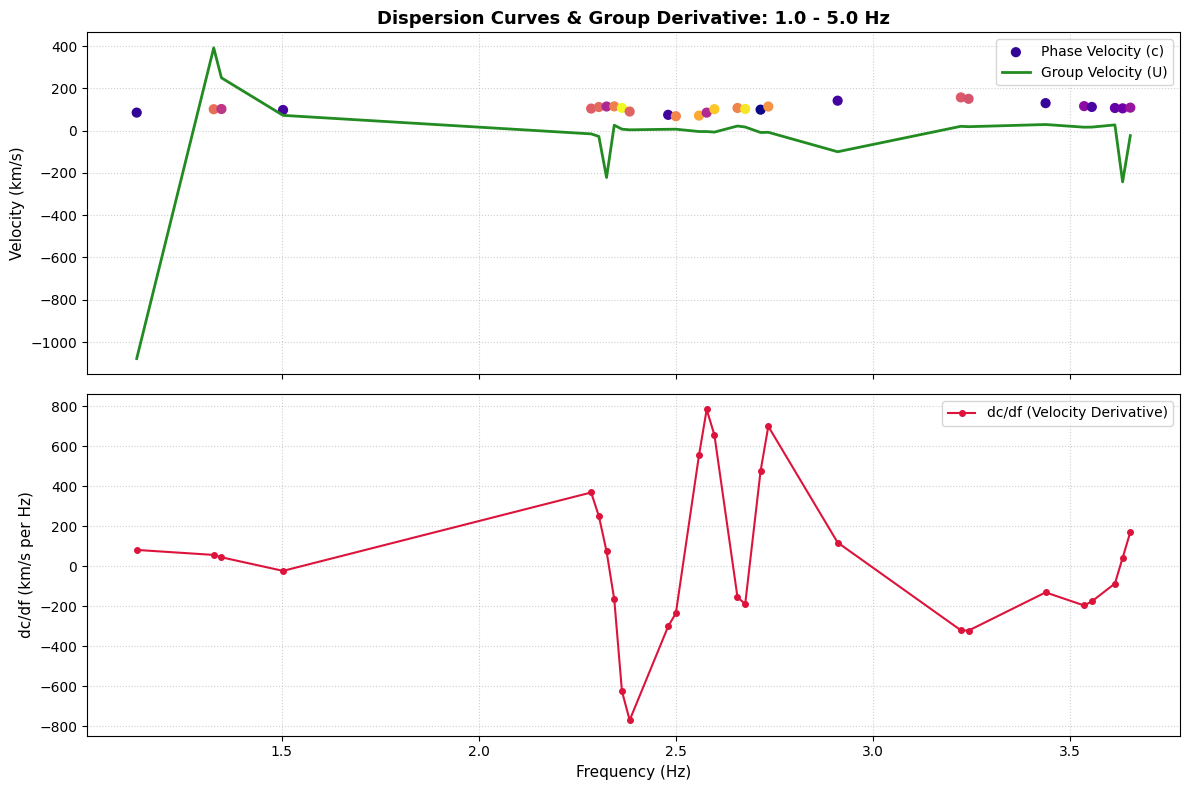

--- Analysis Summary for Band 1.0 - 5.0 Hz ---
Number of points:              28
Mean Phase Velocity:           107.044 km/s
Mean Group Velocity:           -28.488 km/s
Max Derivative magnitude |dc/df|: 783.888


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Define the target frequency band
f_min, f_max = 1.0, 5.0
distance_km = 10.0

# Extract coherent parameters from previous calculations
coherent_freqs = frequencies[coherent_mask]
coherent_lags_sec = time_lags[coherent_mask]
coherent_coh_vals = coh[coherent_mask]

# Filter for the target band and valid travel-times
band_mask = (coherent_freqs >= f_min) & (coherent_freqs <= f_max) & (coherent_lags_sec > 0.05)

if np.any(band_mask):
    f_band = coherent_freqs[band_mask]
    lags_band = coherent_lags_sec[band_mask]
    coh_band = coherent_coh_vals[band_mask]

    # Sort by frequency
    sort_idx = np.argsort(f_band)
    f_sorted = f_band[sort_idx]
    lags_sorted = lags_band[sort_idx]
    coh_sorted = coh_band[sort_idx]

    # 1. Compute Phase Velocity
    c_band = distance_km / lags_sorted
    c_smoothed = gaussian_filter1d(c_band, sigma=1.2)

    # 2. Compute Numerical Derivative (dc/df)
    dc_df_band = np.gradient(c_smoothed, f_sorted)

    # 3. Compute Group Velocity
    u_band = c_smoothed / (1.0 - (f_sorted / c_smoothed) * dc_df_band)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Plot Phase and Group Velocity
    ax1.scatter(f_sorted, c_smoothed, c=coh_sorted, cmap='plasma', s=40, label='Phase Velocity (c)', zorder=3)
    ax1.plot(f_sorted, u_band, color='forestgreen', linewidth=2, label='Group Velocity (U)', zorder=4)
    ax1.set_ylabel('Velocity (km/s)', fontsize=11)
    ax1.set_title(f'Dispersion Curves & Group Derivative: {f_min} - {f_max} Hz', fontsize=13, fontweight='semibold')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # Plot Derivative (dc/df)
    ax2.plot(f_sorted, dc_df_band, color='crimson', marker='o', markersize=4, linestyle='-', label='dc/df (Velocity Derivative)')
    ax2.set_xlabel('Frequency (Hz)', fontsize=11)
    ax2.set_ylabel('dc/df (km/s per Hz)', fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"--- Analysis Summary for Band {f_min} - {f_max} Hz ---")
    print(f"Number of points:              {len(f_sorted)}")
    print(f"Mean Phase Velocity:           {np.mean(c_smoothed):.3f} km/s")
    print(f"Mean Group Velocity:           {np.mean(u_band[np.isfinite(u_band)]):.3f} km/s")
    print(f"Max Derivative magnitude |dc/df|: {np.max(np.abs(dc_df_band)):.3f}")
else:
    print(f"No coherent points found in the selected band: {f_min} to {f_max} Hz")


### 4.2 Group Velocity Derivative Analysis for the High-Frequency Band (5.0 - 7.0 Hz)
Here, we target the higher frequency band containing our strongest peak coherence ($6.328 \text{ Hz}$) to inspect its velocity derivatives.

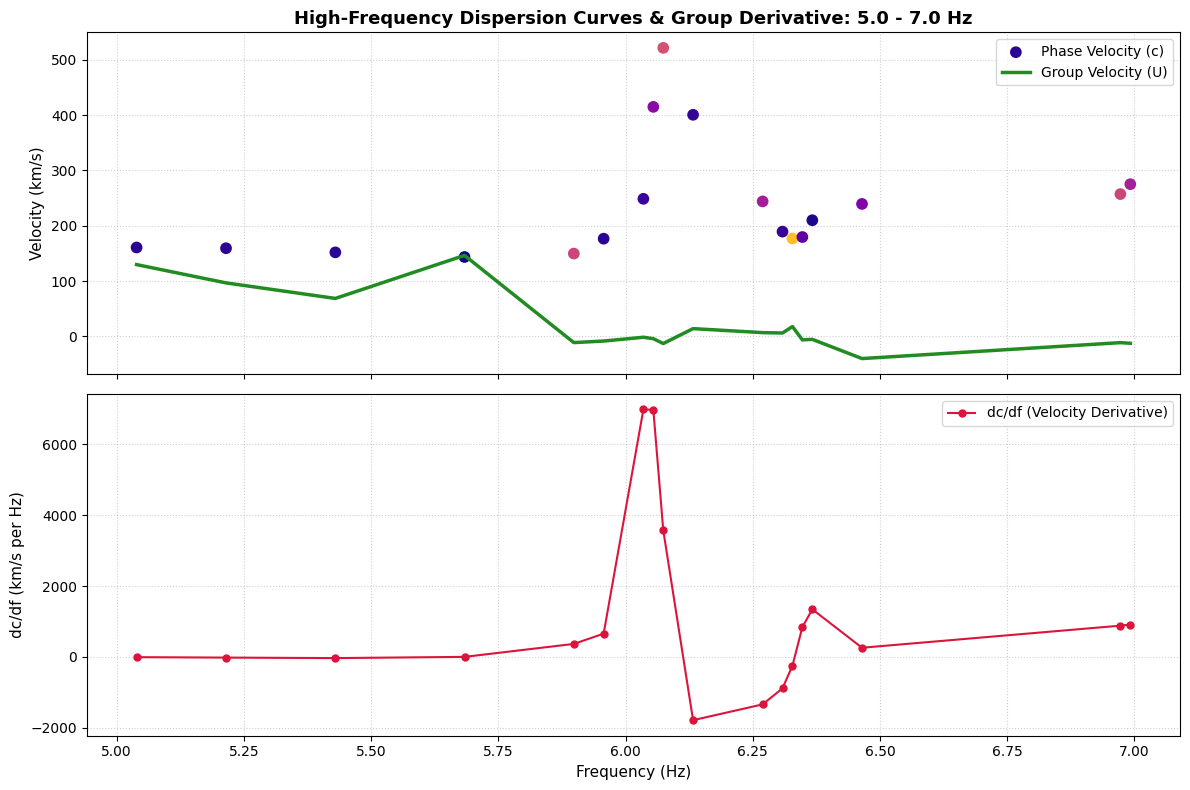

--- Analysis Summary for Band 5.0 - 7.0 Hz ---
Number of points:              18
Mean Phase Velocity:           238.797 km/s
Mean Group Velocity:           20.754 km/s
Max Derivative magnitude |dc/df|: 6988.589


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Define the new target frequency band
f_min, f_max = 5.0, 7.0
distance_km = 10.0

# Extract coherent parameters from previous calculations
coherent_freqs = frequencies[coherent_mask]
coherent_lags_sec = time_lags[coherent_mask]
coherent_coh_vals = coh[coherent_mask]

# Filter for the target band and valid travel-times
band_mask = (coherent_freqs >= f_min) & (coherent_freqs <= f_max) & (np.abs(coherent_lags_sec) > 0.01)

if np.any(band_mask):
    f_band = coherent_freqs[band_mask]
    lags_band = coherent_lags_sec[band_mask]
    coh_band = coherent_coh_vals[band_mask]

    # Sort by frequency
    sort_idx = np.argsort(f_band)
    f_sorted = f_band[sort_idx]
    lags_sorted = lags_band[sort_idx]
    coh_sorted = coh_band[sort_idx]

    # 1. Compute Phase Velocity
    c_band = distance_km / np.abs(lags_sorted)
    c_smoothed = gaussian_filter1d(c_band, sigma=1.0)

    # 2. Compute Numerical Derivative (dc/df)
    dc_df_band = np.gradient(c_smoothed, f_sorted)

    # 3. Compute Group Velocity
    u_band = c_smoothed / (1.0 - (f_sorted / c_smoothed) * dc_df_band)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Plot Phase and Group Velocity
    ax1.scatter(f_sorted, c_smoothed, c=coh_sorted, cmap='plasma', vmin=0.3, vmax=0.8, s=55, label='Phase Velocity (c)', zorder=3)
    ax1.plot(f_sorted, u_band, color='forestgreen', linewidth=2.5, label='Group Velocity (U)', zorder=4)
    ax1.set_ylabel('Velocity (km/s)', fontsize=11)
    ax1.set_title(f'High-Frequency Dispersion Curves & Group Derivative: {f_min} - {f_max} Hz', fontsize=13, fontweight='semibold')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # Plot Derivative (dc/df)
    ax2.plot(f_sorted, dc_df_band, color='crimson', marker='o', markersize=5, linestyle='-', label='dc/df (Velocity Derivative)')
    ax2.set_xlabel('Frequency (Hz)', fontsize=11)
    ax2.set_ylabel('dc/df (km/s per Hz)', fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"--- Analysis Summary for Band {f_min} - {f_max} Hz ---")
    print(f"Number of points:              {len(f_sorted)}")
    print(f"Mean Phase Velocity:           {np.mean(c_smoothed):.3f} km/s")
    print(f"Mean Group Velocity:           {np.mean(u_band[np.isfinite(u_band)]):.3f} km/s")
    print(f"Max Derivative magnitude |dc/df|: {np.max(np.abs(dc_df_band)):.3f}")
else:
    print(f"No coherent points found in the selected band: {f_min} to {f_max} Hz")

### 4.3 Side-by-Side Comparison of the 1–5 Hz and 5–7 Hz Bands
Here we extract and overlay the dispersion curves (Phase and Group Velocities) calculated from both key bands into a single comparison plot to visualize how wave propagation speeds diverge as frequency increases.

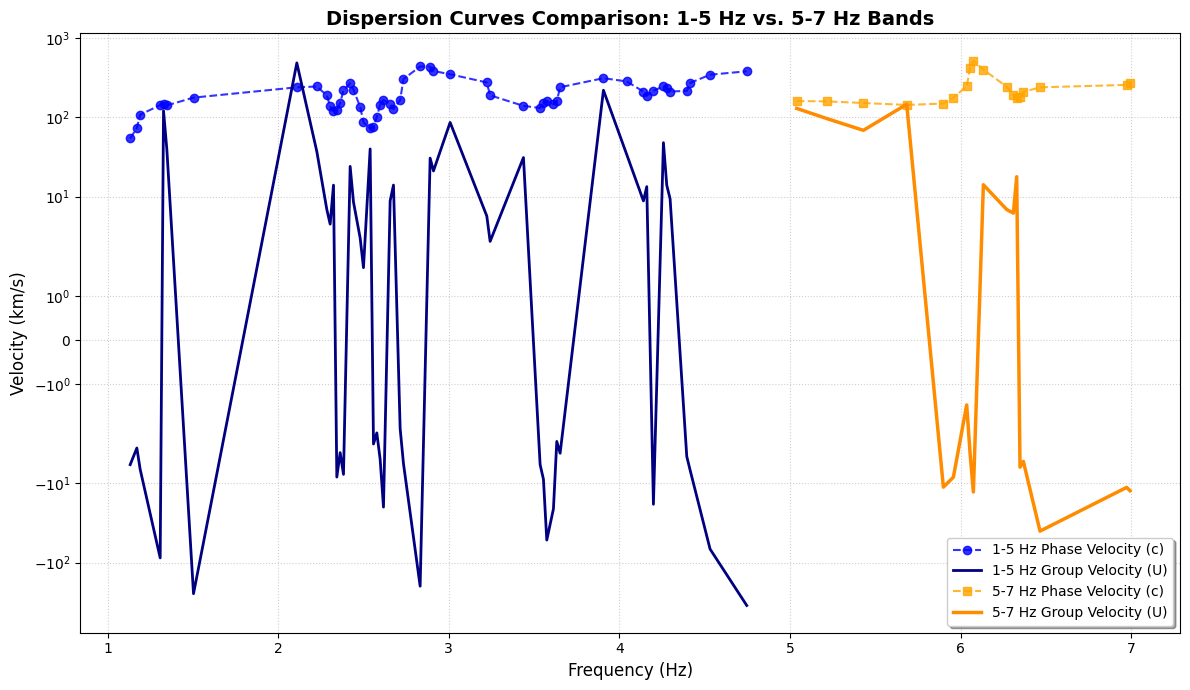

Dispersion Results Comparison Table:
Band (Hz)       | Points     | Mean Phase Vel (km/s)  | Mean Group Vel (km/s) 
---------------------------------------------------------------------------
1.0 - 5.0       | 53         | 200.539                | 3.595                 
5.0 - 7.0       | 18         | 238.797                | 20.754                


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

distance_km = 10.0
coherent_freqs = frequencies[coherent_mask]
coherent_lags_sec = time_lags[coherent_mask]

# Helper function to compute velocities for a specified band
def compute_band_velocities(f_min, f_max, sigma_smooth=1.2):
    mask = (coherent_freqs >= f_min) & (coherent_freqs <= f_max) & (np.abs(coherent_lags_sec) > 0.01)
    if not np.any(mask):
        return None
    f_b = coherent_freqs[mask]
    lags_b = coherent_lags_sec[mask]

    sort_idx = np.argsort(f_b)
    f_sorted = f_b[sort_idx]
    lags_sorted = lags_b[sort_idx]

    c_b = distance_km / np.abs(lags_sorted)
    c_smoothed = gaussian_filter1d(c_b, sigma=sigma_smooth)
    dc_df = np.gradient(c_smoothed, f_sorted)
    u_b = c_smoothed / (1.0 - (f_sorted / c_smoothed) * dc_df)

    return f_sorted, c_smoothed, u_b

# Calculate for both bands
band1_data = compute_band_velocities(1.0, 5.0, sigma_smooth=1.2)
band2_data = compute_band_velocities(5.0, 7.0, sigma_smooth=1.0)

# Plotting comparison
plt.figure(figsize=(12, 7))

if band1_data is not None:
    f1, c1, u1 = band1_data
    plt.plot(f1, c1, color='blue', linestyle='--', label='1-5 Hz Phase Velocity (c)', marker='o', alpha=0.8)
    plt.plot(f1, u1, color='navy', linestyle='-', label='1-5 Hz Group Velocity (U)', linewidth=2)

if band2_data is not None:
    f2, c2, u2 = band2_data
    plt.plot(f2, c2, color='orange', linestyle='--', label='5-7 Hz Phase Velocity (c)', marker='s', alpha=0.8)
    # Mask out non-physical infinite/negative values for clean comparison
    valid_u2 = np.isfinite(u2) & (u2 > -500) & (u2 < 500)
    plt.plot(f2[valid_u2], u2[valid_u2], color='darkorange', linestyle='-', label='5-7 Hz Group Velocity (U)', linewidth=2.5)

plt.title("Dispersion Curves Comparison: 1-5 Hz vs. 5-7 Hz Bands", fontsize=14, fontweight='bold')
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Velocity (km/s)", fontsize=12)
plt.yscale('symlog')  # Use symmetric log scale to handle the wide dynamic range of velocities
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.legend(loc='best', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# Print side-by-side statistics
print("Dispersion Results Comparison Table:")
print("="*75)
print(f"{'Band (Hz)':<15} | {'Points':<10} | {'Mean Phase Vel (km/s)':<22} | {'Mean Group Vel (km/s)':<22}")
print("-"*75)
if band1_data is not None:
    print(f"{'1.0 - 5.0':<15} | {len(band1_data[0]):<10} | {np.mean(band1_data[1]):<22.3f} | {np.mean(band1_data[2][np.isfinite(band1_data[2])]):<22.3f}")
if band2_data is not None:
    print(f"{'5.0 - 7.0':<15} | {len(band2_data[0]):<10} | {np.mean(band2_data[1]):<22.3f} | {np.mean(band2_data[2][np.isfinite(band2_data[2])]):<22.3f}")
print("="*75)

### 5. Quick Listing of Groups and Datasets
Here is a simple example showing how to fetch only the names of all objects or top-level keys inside an HDF5 file.

In [3]:
import h5py

def list_hdf5_contents(hdf5_path):
    with h5py.File(hdf5_path, 'r') as f:
        print("Top-level keys:", list(f.keys()))

        print("\nAll nested paths:")
        # .visit() walks the entire file hierarchy and prints each object path
        f.visit(print)

# Example usage:
# list_hdf5_contents('output.h5')

### 6. Visualize a Slice of the Seismic Data
Below is a script that loads your converted dataset from the HDF5 file and visualizes a 2D slice using Matplotlib.

In [10]:
import h5py
import matplotlib.pyplot as plt

def plot_seismic_slice(hdf5_path, dataset_name='seismic', slice_index=0, axis=0):
    """
    Plots a 2D slice of seismic data from an HDF5 file.
    """
    with h5py.File(hdf5_path, 'r') as f:
        data = f[dataset_name]
        print(f"Dataset shape: {data.shape}")

        # Extract slice based on dimensionality
        if data.ndim == 3:
            if axis == 0:
                slice_data = data[slice_index, :, :]
            elif axis == 1:
                slice_data = data[:, slice_index, :]
            else:
                slice_data = data[:, :, slice_index]
            title = f"Seismic Slice {slice_index} along Axis {axis}"
        elif data.ndim == 2:
            slice_data = data[:, :]
            title = "2D Seismic Profile"
        else:
            raise ValueError(f"Unsupported dataset dimensions: {data.ndim}")

        # Plotting the data
        plt.figure(figsize=(10, 6))
        # 'Seismic' colormap or 'RdBu' is standard for displaying seismic data
        v_max = max(abs(slice_data.min()), abs(slice_data.max())) * 0.5  # Adjust contrast
        im = plt.imshow(slice_data.T, cmap='RdBu', aspect='auto', vmin=-v_max, vmax=v_max)
        plt.colorbar(im, label='Amplitude')
        plt.title(title)
        plt.xlabel('Traces')
        plt.ylabel('Samples')
        plt.tight_layout()
        plt.show()

# Example usage:
# plot_seismic_slice('output.h5', slice_index=50, axis=0)

### 7. Check the Shape of the Data Array in HDF5
Run this cell to quickly print the shape and datatype of your dataset.

In [11]:
import h5py

def print_dataset_shape(hdf5_path, dataset_name='seismic'):
    try:
        with h5py.File(hdf5_path, 'r') as f:
            if dataset_name in f:
                dataset = f[dataset_name]
                print(f"Dataset '{dataset_name}' Shape: {dataset.shape}")
                print(f"Dataset '{dataset_name}' Datatype: {dataset.dtype}")
            else:
                print(f"Dataset '{dataset_name}' not found in the file.")
                print(f"Available keys: {list(f.keys())}")
    except FileNotFoundError:
        print(f"Error: File not found at '{hdf5_path}'. Make sure you have converted and saved your file first.")

# Replace 'output.h5' with your actual HDF5 file path if different
print_dataset_shape('output.h5')

Error: File not found at 'output.h5'. Make sure you have converted and saved your file first.


### 8. List Workspace Files
Run this cell to list all files in the current working directory. This will help you verify if your `.segy` or `.sgy` file has successfully uploaded.

In [12]:
import os

# List files in the current workspace directory
print("Files in current workspace:")
files = os.listdir('.')
for file in sorted(files):
    print(f"- {file}")

print("\n--- Running system 'ls' command ---")
!ls -lh

Files in current workspace:
- .config
- drive
- sample_data

--- Running system 'ls' command ---
total 8.0K
drwx------ 5 root root 4.0K Sep 26 12:51 drive
drwxr-xr-x 1 root root 4.0K Sep 16 13:26 sample_data
